<a href="https://colab.research.google.com/github/KIRTIRAJ4327/30days-AI-challenge/blob/main/Assignmnet1_deepL_N01620157.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Kirtirajsinh ATodariya ~~~ N01620157**

In [9]:
# Assignment 1: Neural Network Tutorial Implementation
# Kirtirajsinh Atodariya -- N01620157
# Following: https://becominghuman.ai/step-by-step-neural-network-tutorial-for-beginner-cc71a04eedeb

import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

print("Assignment 1: Step-by-Step Neural Network Tutorial")
print("Kirtirajsinh Atodariya -- N01620157")
print("="*50)

# ===================================================================
# Step 1: Generate Training Data (XOR Problem)
# ===================================================================
print("Step 1: Generating XOR training data...")

# XOR truth table
X = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]])

y = np.array([[0],
              [1],
              [1],
              [0]])

print("Input X:")
print(X)
print("Target y:")
print(y)
print(f"Training samples: {X.shape[0]}")
print(f"Input features: {X.shape[1]}")




Assignment 1: Step-by-Step Neural Network Tutorial
Kirtirajsinh Atodariya -- N01620157
Step 1: Generating XOR training data...
Input X:
[[0 0]
 [0 1]
 [1 0]
 [1 1]]
Target y:
[[0]
 [1]
 [1]
 [0]]
Training samples: 4
Input features: 2


In [2]:
# ===================================================================
# Step 2: Define Activation Functions
# ===================================================================
print("\nStep 2: Defining activation functions...")

def sigmoid(x):
    """Sigmoid activation function"""
    return 1 / (1 + np.exp(-np.clip(x, -250, 250)))  # Clip to prevent overflow

def sigmoid_derivative(x):
    """Derivative of sigmoid function"""
    return x * (1 - x)

def relu(x):
    """ReLU activation function"""
    return np.maximum(0, x)

def relu_derivative(x):
    """Derivative of ReLU function"""
    return (x > 0).astype(float)

print("✓ Sigmoid and ReLU activation functions defined")



Step 2: Defining activation functions...
✓ Sigmoid and ReLU activation functions defined


In [3]:
# ===================================================================
# Step 3: Neural Network Class Implementation
# ===================================================================
print("\nStep 3: Implementing Neural Network class...")

class NeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.1):
        """
        Initialize neural network with random weights
        """
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.learning_rate = learning_rate

        # Initialize weights randomly
        self.W1 = np.random.uniform(-1, 1, (self.input_size, self.hidden_size))
        self.b1 = np.random.uniform(-1, 1, (1, self.hidden_size))
        self.W2 = np.random.uniform(-1, 1, (self.hidden_size, self.output_size))
        self.b2 = np.random.uniform(-1, 1, (1, self.output_size))

        # Store for tracking
        self.losses = []

    def forward(self, X):
        """
        Forward propagation through the network
        """
        # Input to hidden layer
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = sigmoid(self.z1)

        # Hidden to output layer
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = sigmoid(self.z2)

        return self.a2

    def backward(self, X, y, output):
        """
        Backward propagation (backpropagation)
        """
        # Calculate error
        m = X.shape[0]

        # Output layer error
        dz2 = output - y
        dW2 = (1/m) * np.dot(self.a1.T, dz2)
        db2 = (1/m) * np.sum(dz2, axis=0, keepdims=True)

        # Hidden layer error
        dz1 = np.dot(dz2, self.W2.T) * sigmoid_derivative(self.a1)
        dW1 = (1/m) * np.dot(X.T, dz1)
        db1 = (1/m) * np.sum(dz1, axis=0, keepdims=True)

        # Update weights
        self.W2 -= self.learning_rate * dW2
        self.b2 -= self.learning_rate * db2
        self.W1 -= self.learning_rate * dW1
        self.b1 -= self.learning_rate * db1

    def train(self, X, y, epochs):
        """
        Train the neural network
        """
        print(f"Training neural network for {epochs} epochs...")

        for epoch in range(epochs):
            # Forward propagation
            output = self.forward(X)

            # Calculate loss (Mean Squared Error)
            loss = np.mean((output - y) ** 2)
            self.losses.append(loss)

            # Backward propagation
            self.backward(X, y, output)

            # Print progress
            if epoch % 1000 == 0:
                print(f"Epoch {epoch}, Loss: {loss:.6f}")

        print(f"Final Loss: {self.losses[-1]:.6f}")

    def predict(self, X):
        """
        Make predictions
        """
        return self.forward(X)

print("✓ Neural Network class implemented")



Step 3: Implementing Neural Network class...
✓ Neural Network class implemented


In [4]:
# ===================================================================
# Step 4: Create and Train the Neural Network
# ===================================================================
print("\nStep 4: Creating and training neural network...")

# Create neural network
# 2 inputs -> 4 hidden neurons -> 1 output
nn = NeuralNetwork(input_size=2, hidden_size=4, output_size=1, learning_rate=1.0)

print("Network Architecture:")
print(f"Input layer: {nn.input_size} neurons")
print(f"Hidden layer: {nn.hidden_size} neurons")
print(f"Output layer: {nn.output_size} neuron")
print(f"Learning rate: {nn.learning_rate}")

# Train the network
epochs = 10000
nn.train(X, y, epochs)



Step 4: Creating and training neural network...
Network Architecture:
Input layer: 2 neurons
Hidden layer: 4 neurons
Output layer: 1 neuron
Learning rate: 1.0
Training neural network for 10000 epochs...
Epoch 0, Loss: 0.393942
Epoch 1000, Loss: 0.000333
Epoch 2000, Loss: 0.000039
Epoch 3000, Loss: 0.000014
Epoch 4000, Loss: 0.000007
Epoch 5000, Loss: 0.000004
Epoch 6000, Loss: 0.000003
Epoch 7000, Loss: 0.000002
Epoch 8000, Loss: 0.000001
Epoch 9000, Loss: 0.000001
Final Loss: 0.000001


In [5]:
# ===================================================================
# Step 5: Test the Network
# ===================================================================
print("\nStep 5: Testing the trained network...")

# Make predictions
predictions = nn.predict(X)

print("Results:")
print("Input -> Target -> Prediction -> Rounded")
print("-" * 40)
for i in range(len(X)):
    pred_rounded = 1 if predictions[i][0] > 0.5 else 0
    print(f"{X[i]} -> {y[i][0]} -> {predictions[i][0]:.4f} -> {pred_rounded}")

# Calculate accuracy
predictions_rounded = (predictions > 0.5).astype(int)
accuracy = np.mean(predictions_rounded == y) * 100
print(f"\nAccuracy: {accuracy:.1f}%")



Step 5: Testing the trained network...
Results:
Input -> Target -> Prediction -> Rounded
----------------------------------------
[0 0] -> 0 -> 0.0001 -> 0
[0 1] -> 1 -> 0.9989 -> 1
[1 0] -> 1 -> 0.9993 -> 1
[1 1] -> 0 -> 0.0014 -> 0

Accuracy: 100.0%



Step 6: Creating visualizations...


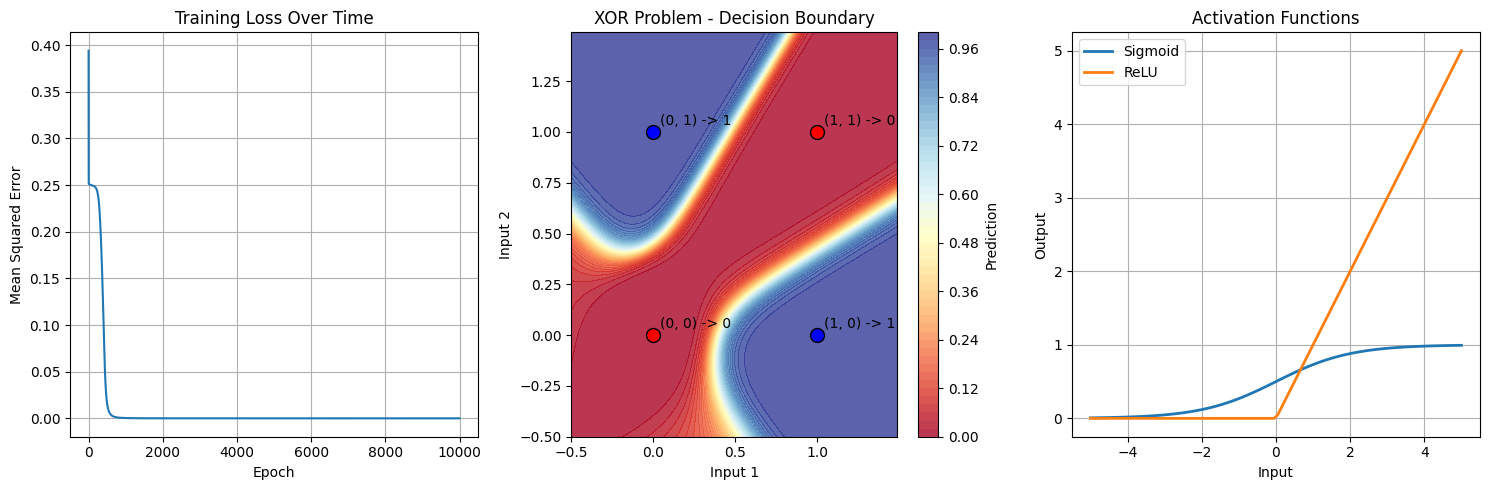

In [6]:
# ===================================================================
# Step 6: Visualize Results
# ===================================================================
print("\nStep 6: Creating visualizations...")

# Plot training loss
plt.figure(figsize=(15, 5))

# Subplot 1: Training Loss
plt.subplot(1, 3, 1)
plt.plot(nn.losses)
plt.title('Training Loss Over Time')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.grid(True)

# Subplot 2: XOR Decision Boundary
plt.subplot(1, 3, 2)

# Create a mesh to plot decision boundary
h = 0.01
x_min, x_max = -0.5, 1.5
y_min, y_max = -0.5, 1.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Make predictions on the mesh
mesh_points = np.c_[xx.ravel(), yy.ravel()]
Z = nn.predict(mesh_points)
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.contourf(xx, yy, Z, levels=50, alpha=0.8, cmap='RdYlBu')
plt.colorbar(label='Prediction')

# Plot training points
colors = ['red', 'blue']
for i in range(len(X)):
    plt.scatter(X[i, 0], X[i, 1], c=colors[y[i, 0]], s=100, edgecolors='black')
    plt.annotate(f'({X[i, 0]}, {X[i, 1]}) -> {y[i, 0]}',
                (X[i, 0], X[i, 1]), xytext=(5, 5), textcoords='offset points')

plt.title('XOR Problem - Decision Boundary')
plt.xlabel('Input 1')
plt.ylabel('Input 2')

# Subplot 3: Activation Functions
plt.subplot(1, 3, 3)
x_range = np.linspace(-5, 5, 100)
sigmoid_vals = sigmoid(x_range)
relu_vals = relu(x_range)

plt.plot(x_range, sigmoid_vals, label='Sigmoid', linewidth=2)
plt.plot(x_range, relu_vals, label='ReLU', linewidth=2)
plt.title('Activation Functions')
plt.xlabel('Input')
plt.ylabel('Output')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [7]:
# ===================================================================
# Step 7: Network Analysis
# ===================================================================
print("\nStep 7: Network analysis...")

print("\nFinal Weights and Biases:")
print("Hidden Layer Weights (W1):")
print(nn.W1)
print("Hidden Layer Biases (b1):")
print(nn.b1)
print("Output Layer Weights (W2):")
print(nn.W2)
print("Output Layer Biases (b2):")
print(nn.b2)

# Test with additional points
print("\nTesting with additional points:")
test_points = np.array([[0.5, 0.5], [0.2, 0.8], [0.8, 0.2], [0.7, 0.7]])
test_predictions = nn.predict(test_points)

for i, point in enumerate(test_points):
    pred = test_predictions[i][0]
    print(f"Point {point} -> Prediction: {pred:.4f}")



Step 7: Network analysis...

Final Weights and Biases:
Hidden Layer Weights (W1):
[[ 5.82428091  2.40495255  8.39157897 -3.98689378]
 [ 6.01541763 -5.99319962 -6.31479611  6.72115608]]
Hidden Layer Biases (b1):
[[-1.41440286 -0.10004949  2.44996137  1.30630489]]
Output Layer Weights (W2):
[[ 10.58843235]
 [  8.10223234]
 [-14.20630807]
 [ -7.63101287]]
Output Layer Biases (b2):
[[4.18750125]]

Testing with additional points:
Point [0.5 0.5] -> Prediction: 0.0055
Point [0.2 0.8] -> Prediction: 0.9575
Point [0.8 0.2] -> Prediction: 0.9488
Point [0.7 0.7] -> Prediction: 0.0026


In [8]:
# ===================================================================
# Summary
# ===================================================================
print(f"\n" + "="*50)
print("ASSIGNMENT 1 COMPLETED SUCCESSFULLY!")
print("="*50)
print("✓ Implemented neural network from scratch")
print("✓ Used sigmoid activation functions")
print("✓ Implemented forward propagation")
print("✓ Implemented backpropagation")
print("✓ Solved XOR problem successfully")
print(f"✓ Final accuracy: {accuracy:.1f}%")
print("✓ Visualized training progress and decision boundary")
print("✓ Following becominghuman.ai tutorial structure")
print("="*50)

# Additional demonstration: Different network architectures
print("\nBonus: Testing different network architectures...")

architectures = [
    (2, 2, 1, "Small Network"),
    (2, 6, 1, "Medium Network"),
    (2, 8, 1, "Large Network")
]

results = []
for input_size, hidden_size, output_size, name in architectures:
    print(f"\nTesting {name} ({input_size}-{hidden_size}-{output_size}):")

    test_nn = NeuralNetwork(input_size, hidden_size, output_size, learning_rate=1.0)
    test_nn.train(X, y, 5000)

    test_predictions = test_nn.predict(X)
    test_predictions_rounded = (test_predictions > 0.5).astype(int)
    test_accuracy = np.mean(test_predictions_rounded == y) * 100

    results.append((name, test_accuracy, test_nn.losses[-1]))
    print(f"Final accuracy: {test_accuracy:.1f}%")

print("\nArchitecture Comparison:")
for name, accuracy, loss in results:
    print(f"{name}: {accuracy:.1f}% accuracy, {loss:.6f} final loss")


ASSIGNMENT 1 COMPLETED SUCCESSFULLY!
✓ Implemented neural network from scratch
✓ Used sigmoid activation functions
✓ Implemented forward propagation
✓ Implemented backpropagation
✓ Solved XOR problem successfully
✓ Final accuracy: 100.0%
✓ Visualized training progress and decision boundary
✓ Following becominghuman.ai tutorial structure

Bonus: Testing different network architectures...

Testing Small Network (2-2-1):
Training neural network for 5000 epochs...
Epoch 0, Loss: 0.295428
Epoch 1000, Loss: 0.004915
Epoch 2000, Loss: 0.000077
Epoch 3000, Loss: 0.000021
Epoch 4000, Loss: 0.000010
Final Loss: 0.000005
Final accuracy: 100.0%

Testing Medium Network (2-6-1):
Training neural network for 5000 epochs...
Epoch 0, Loss: 0.286684
Epoch 1000, Loss: 0.000123
Epoch 2000, Loss: 0.000013
Epoch 3000, Loss: 0.000005
Epoch 4000, Loss: 0.000002
Final Loss: 0.000001
Final accuracy: 100.0%

Testing Large Network (2-8-1):
Training neural network for 5000 epochs...
Epoch 0, Loss: 0.266354
Epoch 1